In [3]:
!git clone https://github.com/MyungKyuYi/AI-class.git

Cloning into 'AI-class'...
remote: Enumerating objects: 398, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 398 (delta 76), reused 23 (delta 23), pack-reused 284 (from 1)
Receiving objects: 100% (398/398), 33.33 MiB | 27.41 MiB/s, done.
Resolving deltas: 100% (186/186), done.


In [8]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

import datetime
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. 데이터 로드
df = pd.read_csv('/content/AI-class/TSLA.csv')
data = df[['Open', 'High', 'Low', 'Close']]

In [10]:
data

,Open,High,Low,Close
0,3.800000,5.000000,3.508000,4.778000
1,5.158000,6.084000,4.660000,4.766000
2,5.000000,5.184000,4.054000,4.392000
3,4.600000,4.620000,3.742000,3.840000
4,4.000000,4.000000,3.166000,3.222000
...,...,...,...,...
2951,874.489990,907.849976,867.390015,905.390015
2952,914.979980,942.849976,907.090027,921.159973
2953,930.000000,997.859985,921.750000,993.979980
2954,979.940002,1040.699951,976.400024,999.109985


In [11]:
# 2. 정규화
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [12]:
window = 10  # 과거 10일의 데이터를 사용
feature_count = 4 # Open, High, Low, Close 4개 피처

In [13]:
X, y = [], []
for i in range(len(data) - window):
        # i 부터 (i + window_size) 전까지 10일간의 O,H,L,C 데이터
    X.append(data[i:(i + window), :feature_count])

        # (i + window_size) 일 (즉, 11일차)의 'Close' 가격 (Close는 4번째 열, 인덱스 3)
    y.append(data[i + window, 3])
X, y = np.array(X), np.array(y)

In [14]:
# 4. 훈련 / 테스트 세트 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False,  #  시계열 데이터는 절대 섞지 않는다.
    random_state=42
)

In [17]:
# RNN 모델
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window,feature_count)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=8)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.8819e-04
Epoch 2/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.9330e-06
Epoch 3/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.1709e-06
Epoch 4/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.2269e-06
Epoch 5/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 4.2771e-06
Epoch 6/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.7035e-06
Epoch 7/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.4348e-06
Epoch 8/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.5543e-06
Epoch 9/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5920e-06
Epoch 10/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.4879e-06
Epoch 11/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3207e-06
Epoch 12/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3405e-06
Epoch 13/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.9121e-06
Epoch 14/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.4332e-06
Epoch 15/50

In [18]:
# LSTM 모델
model_2 = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(window,feature_count)),
    tf.keras.layers.Dense(1)
])
model_2.compile(optimizer='adam', loss='mse')
model_2.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 5.3118e-05
Epoch 2/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.5974e-06
Epoch 3/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.3229e-06
Epoch 4/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.3472e-06
Epoch 5/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.7285e-06
Epoch 6/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 3.0327e-06
Epoch 7/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.2062e-06
Epoch 8/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5867e-06
Epoch 9/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.2573e-06
Epoch 10/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.4111e-06
Epoch 11/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1845e-06
Epoch 12/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2111e-06
Epoch 13/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.6619e-06
Epoch 14/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.2019e-06
Epoch 15/50

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RNN 예측 결과


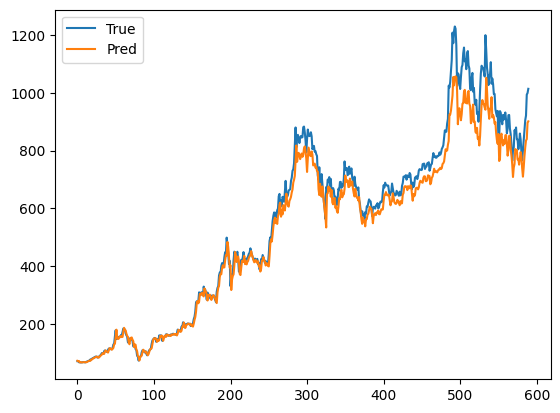

LSTM 예측 결과


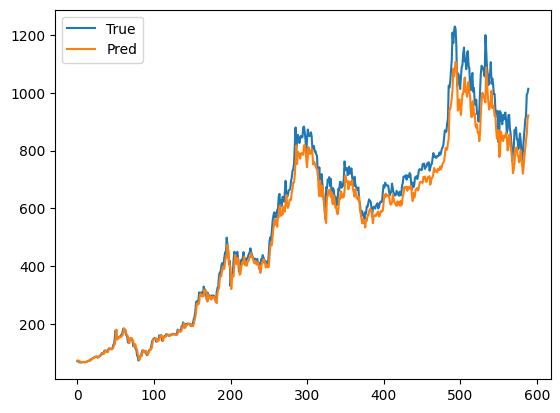

In [25]:

pred_rnn = model.predict(X_test)     # RNN 모델 예측
pred_lstm = model_2.predict(X_test)  # LSTM 모델 예측


#학습할 때 특성 4개를 사용해서 복구할 때도 4개가 필요함 -> 예측하는 close값에 의미없는 0을 포함해서 scaler에 넣어줘야함
y_test_dummy = np.zeros((len(y_test), 4))

y_test_dummy[:, 3] = y_test
y_test_original = scaler.inverse_transform(y_test_dummy)[:, 3]

pred_rnn_dummy = np.zeros((len(pred_rnn), 4))

pred_rnn_dummy[:, 3] = pred_rnn.flatten()

pred_rnn_original = scaler.inverse_transform(pred_rnn_dummy)[:, 3]


pred_lstm_dummy = np.zeros((len(pred_lstm), 4))

pred_lstm_dummy[:, 3] = pred_lstm.flatten()


pred_lstm_original = scaler.inverse_transform(pred_lstm_dummy)[:, 3]



print("RNN 예측 결과")
plt.plot(y_test_original, label='True')
plt.plot(pred_rnn_original, label='Pred')
plt.legend()
plt.show()

print("LSTM 예측 결과")
plt.plot(y_test_original, label='True')
plt.plot(pred_lstm_original, label='Pred')
plt.legend()
plt.show()

In [26]:
final_train_mse_1 = model.evaluate(X_train, y_train, verbose=0)
print("RNN 모델의 최종 MSE: ",final_train_mse_1)


final_train_mse_2 = model_2.evaluate(X_train, y_train, verbose=0)
print("LSTM 모델의 최종 MSE: ",final_train_mse_2)

RNN 모델의 최종 MSE:  1.052861989592202e-06
LSTM 모델의 최종 MSE:  1.977210104087135e-06
